# Multimodal Movie Recommender


## Imports


In [1]:
import importlib.util
import subprocess
import sys

required_packages = {
    'numpy': 'numpy',
    'pandas': 'pandas',
    'matplotlib': 'matplotlib',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow',
}

missing = [pkg for module, pkg in required_packages.items() if importlib.util.find_spec(module) is None]
if missing:
    print('Installing:', ', '.join(missing))
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *missing])
else:
    print('All required packages are already installed.')


Installing: tensorflow


In [2]:
import os
os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '2')
os.environ.setdefault('TF_ENABLE_ONEDNN_OPTS', '0')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.decomposition import TruncatedSVD

print('TensorFlow version:', tf.__version__)
print('GPU available:', tf.config.list_physical_devices('GPU'))

USE_SAMPLE = True
USE_POSTER_SVD = True
POSTER_SVD_DIM = 64


def resolve_data_dir():
    env_dir = os.environ.get('MOVIE_REC_DATA_DIR')
    if env_dir:
        return Path(env_dir).expanduser().resolve()

    candidates = [
        Path.cwd() / 'MultimodalMovieDataset_v2',
        Path.cwd() / 'dataset' / 'MultimodalMovieDataset_v2',
        Path.cwd(),
        Path.cwd() / 'MultimodalMovieDataset',
        Path.cwd() / 'dataset' / 'MultimodalMovieDataset',
    ]
    required = ['model_sample_500k.csv', 'movie2idx.csv', 'user2idx.csv', 'poster_embeddings.npy']
    for candidate in candidates:
        if all((candidate / name).exists() for name in required):
            return candidate.resolve()
    return Path.cwd().resolve()


DATA_DIR = resolve_data_dir()

EMBEDDING_DIM   = 32
BATCH_SIZE      = 1024
EPOCHS_BASELINE = 20
EPOCHS_MULTI    = 20
SEED            = 42

RATING_MIN = 0.5
RATING_MAX = 5.0

tf.random.set_seed(SEED)
np.random.seed(SEED)

print('Data folder:', DATA_DIR)


I0000 00:00:1779573719.779465   11362 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779573719.838620   11362 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779573721.064540   11362 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.21.0
GPU available: []
Data folder: /home/muribr/neural network group project


W0000 00:00:1779573722.030595   11362 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Load Data


In [3]:
def require_file(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Missing required file: {path}')
    return path


TRAINING_USECOLS = [
    'userId', 'movieId', 'rating', 'timestamp', 'user_idx', 'movie_idx',
    'final_title', 'final_genres_str', 'poster_url', 'poster_url_source',
    'poster_imdb_score', 'meta_vote_average', 'meta_vote_count',
    'meta_popularity', 'meta_runtime', 'release_year', 'meta_original_language'
]


def read_training_csv(path):
    return pd.read_csv(path, usecols=lambda c: c in TRAINING_USECOLS)


def load_training_frame(data_dir, use_sample=True):
    if use_sample:
        sample_path = data_dir / 'model_sample_500k.csv'
        if sample_path.exists():
            print(f'Loading sample file: {sample_path.name}')
            return read_training_csv(sample_path), sample_path.name
        print('model_sample_500k.csv not found; falling back to full data loading.')

    model_path = data_dir / 'model_df_clean.csv'
    if model_path.exists():
        print(f'Loading denormalized full file: {model_path.name}')
        return read_training_csv(model_path), model_path.name

    ratings_path = require_file(data_dir / 'final_ratings_clean.csv')
    movies_path = require_file(data_dir / 'final_movie_features_clean.csv')
    print('model_df_clean.csv not found; merging final_ratings_clean.csv + final_movie_features_clean.csv')
    ratings = pd.read_csv(ratings_path)
    movie_cols = [
        'movieId', 'movie_idx', 'final_title', 'final_genres_str', 'poster_url',
        'poster_imdb_score', 'meta_vote_average', 'meta_vote_count',
        'meta_popularity', 'meta_runtime', 'release_year',
        'meta_original_language'
    ]
    optional_cols = ['poster_url_source']
    movie_features = pd.read_csv(movies_path, usecols=lambda c: c in movie_cols + optional_cols)
    df_full = ratings.merge(movie_features, on=['movieId', 'movie_idx'], how='left')
    return df_full, 'final_ratings_clean.csv + final_movie_features_clean.csv'


df, loaded_from = load_training_frame(DATA_DIR, USE_SAMPLE)

user2idx_df  = pd.read_csv(require_file(DATA_DIR / 'user2idx.csv'))
movie2idx_df = pd.read_csv(require_file(DATA_DIR / 'movie2idx.csv'))

N_USERS  = int(user2idx_df['user_idx'].max()) + 1
N_MOVIES = int(movie2idx_df['movie_idx'].max()) + 1

if df['user_idx'].max() >= N_USERS:
    raise ValueError('df contains user_idx values outside user2idx.csv')
if df['movie_idx'].max() >= N_MOVIES:
    raise ValueError('df contains movie_idx values outside movie2idx.csv')

poster_path = require_file(DATA_DIR / 'poster_embeddings.npy')
poster_raw = np.load(poster_path).astype(np.float32, copy=False)
if poster_raw.ndim != 2:
    raise ValueError(f'poster_embeddings.npy must be 2-D, got shape {poster_raw.shape}')

if poster_raw.shape[0] < N_MOVIES:
    pad = np.zeros((N_MOVIES - poster_raw.shape[0], poster_raw.shape[1]), dtype=np.float32)
    poster_raw = np.vstack([poster_raw, pad])
    print(f'Padded poster embeddings to {poster_raw.shape} to match movie2idx.csv')
elif poster_raw.shape[0] > N_MOVIES:
    poster_raw = poster_raw[:N_MOVIES]
    print(f'Trimmed poster embeddings to {poster_raw.shape} to match movie2idx.csv')

poster_available = np.any(poster_raw != 0, axis=1)
unique_df_movies = np.sort(df['movie_idx'].unique())
covered_in_df = int(poster_available[unique_df_movies].sum())

poster_model = np.zeros_like(poster_raw, dtype=np.float32)
if poster_available.any():
    poster_mean = poster_raw[poster_available].mean(axis=0, keepdims=True)
    poster_std = poster_raw[poster_available].std(axis=0, keepdims=True) + 1e-6
    poster_model[poster_available] = (poster_raw[poster_available] - poster_mean) / poster_std

if USE_POSTER_SVD and poster_model.shape[1] > POSTER_SVD_DIM and poster_available.sum() > POSTER_SVD_DIM:
    svd = TruncatedSVD(n_components=POSTER_SVD_DIM, random_state=SEED)
    reduced = np.zeros((N_MOVIES, POSTER_SVD_DIM), dtype=np.float32)
    reduced_present = svd.fit_transform(poster_model[poster_available]).astype(np.float32)
    red_mean = reduced_present.mean(axis=0, keepdims=True)
    red_std = reduced_present.std(axis=0, keepdims=True) + 1e-6
    reduced[poster_available] = (reduced_present - red_mean) / red_std
    poster_model = reduced
    print(f'Poster SVD dim: {POSTER_SVD_DIM}, explained variance: {svd.explained_variance_ratio_.sum():.3f}')

poster_embeddings = np.concatenate(
    [poster_model.astype(np.float32), poster_available.astype(np.float32)[:, None]],
    axis=1
)
POSTER_DIM = poster_embeddings.shape[1]

del poster_raw

print(f'Rows loaded       : {len(df):,} from {loaded_from}')
print(f'Total users       : {N_USERS:,}')
print(f'Total movies      : {N_MOVIES:,}')
print(f'Poster dim        : {POSTER_DIM} ({POSTER_DIM - 1} visual + availability flag)')
print(f'Poster coverage   : {poster_available.sum():,} / {N_MOVIES:,} movies')
print(f'Coverage in df     : {covered_in_df:,} / {len(unique_df_movies):,} unique movies')
if 'poster_url' in df.columns:
    rows_with_poster_url = int(df['poster_url'].notna().sum())
    unique_with_poster_url = int(df.drop_duplicates('movie_idx')['poster_url'].notna().sum())
    print(f'Rows with poster URL in df: {rows_with_poster_url:,} / {len(df):,}')
    print(f'Unique movies with poster URL in df: {unique_with_poster_url:,} / {len(unique_df_movies):,}')
    if unique_with_poster_url - covered_in_df > 500:
        print('Warning: many movies have poster URLs but no embedding yet. Re-run extract_poster_embeddings.py for this DATA_DIR.')
print(f'Rating range      : {df.rating.min()} - {df.rating.max()}')
df.head(3)


Loading sample file: model_sample_500k.csv
Poster SVD dim: 64, explained variance: 0.458
Rows loaded       : 500,000 from model_sample_500k.csv
Total users       : 162,541
Total movies      : 59,047
Poster dim        : 65 (64 visual + availability flag)
Poster coverage   : 58,228 / 59,047 movies
Coverage in df     : 18,230 / 18,311 unique movies
Rows with poster URL in df: 499,928 / 500,000
Unique movies with poster URL in df: 18,280 / 18,311
Rating range      : 0.5 - 5.0


,userId,movieId,rating,timestamp,user_idx,movie_idx,final_title,final_genres_str,poster_url,poster_url_source,poster_imdb_score,meta_vote_average,meta_vote_count,meta_popularity,meta_runtime,release_year,meta_original_language
0,26136,3618,3.0,965671576,26135,3519,Small Time Crooks,Action|Comedy|Crime,https://image.tmdb.org/t/p/w342/eIJRFZFDmh0xXP...,tmdb_all,6.7,6.4,155.0,9.569183,94.0,2000.0,en
1,137640,71264,3.0,1318486314,137639,13750,Cloudy with a Chance of Meatballs,Animation|Comedy|Family|Fantasy|IMAX,https://image.tmdb.org/t/p/w342/qhOhIKf7QEyQ5d...,tmdb_all,7.0,6.5,1799.0,11.665693,90.0,2009.0,en
2,119795,27773,4.0,1458254108,119794,9334,Oldboy,Drama|Thriller|Mystery|Action,https://image.tmdb.org/t/p/w342/pWDtjs568ZfOTM...,tmdb_all,8.4,8.0,2000.0,10.616859,120.0,2003.0,ko


## Data Check


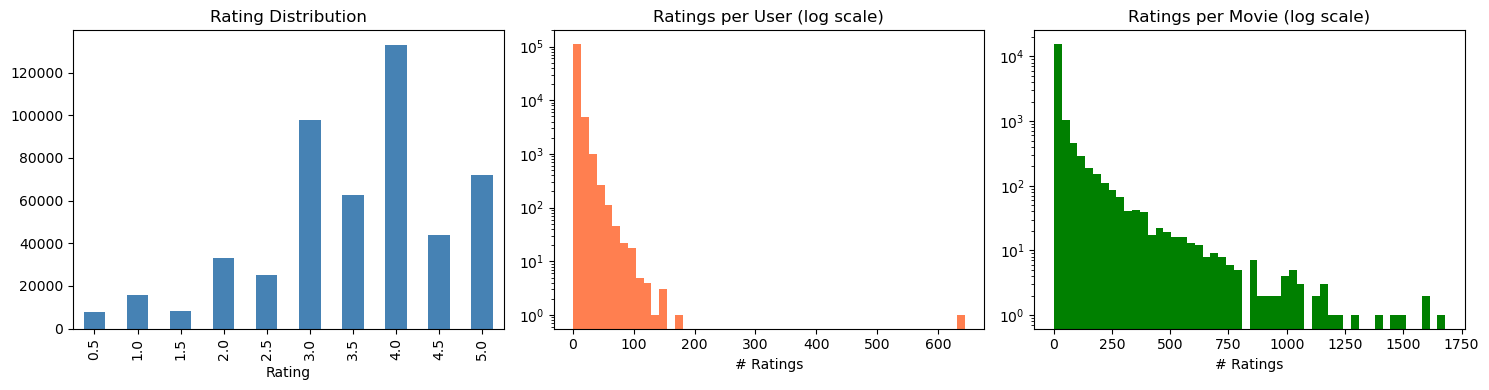

Missing values:
user_idx               0
movie_idx              0
rating                 0
final_genres_str      22
meta_vote_average      0
meta_vote_count        0
meta_popularity        0
meta_runtime           0
release_year         224
dtype: int64


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')

ratings_per_user = df.groupby('user_idx').size()
axes[1].hist(ratings_per_user, bins=50, color='coral', log=True)
axes[1].set_title('Ratings per User')
axes[1].set_xlabel('Count')

ratings_per_movie = df.groupby('movie_idx').size()
axes[2].hist(ratings_per_movie, bins=50, color='green', log=True)
axes[2].set_title('Ratings per Movie')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.show()

print('Missing values:')
print(df[['user_idx','movie_idx','rating','final_genres_str',
          'meta_vote_average','meta_vote_count','meta_popularity',
          'meta_runtime','release_year']].isnull().sum())


## Metadata Features


In [5]:
movie_features = df[['movie_idx','final_genres_str','meta_vote_average',
                      'meta_vote_count','meta_popularity',
                      'meta_runtime','release_year']].drop_duplicates('movie_idx').copy()

movie_features['final_genres_str'] = movie_features['final_genres_str'].fillna('')
genre_lists = movie_features['final_genres_str'].apply(lambda x: x.split('|') if x else ['Unknown'])

mlb = MultiLabelBinarizer()
genre_matrix = mlb.fit_transform(genre_lists)

print(f'Genres found ({len(mlb.classes_)}):', list(mlb.classes_))
print(f'Genre matrix shape: {genre_matrix.shape}')


Genres found (29): ['Action', 'Adult', 'Adventure', 'Animation', 'Biography', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Family', 'Fantasy', 'Foreign', 'History', 'Horror', 'IMAX', 'Music', 'Mystery', 'News', 'Noir', 'Romance', 'Science Fiction', 'Short', 'Sport', 'TV Movie', 'Talk-Show', 'Thriller', 'Unknown', 'War', 'Western']
Genre matrix shape: (18311, 29)


In [6]:
numeric_cols = ['meta_vote_average', 'meta_vote_count', 'meta_popularity',
                'meta_runtime', 'release_year']

for col in ['meta_vote_count', 'meta_popularity']:
    movie_features[col] = np.log1p(movie_features[col])

for col in numeric_cols:
    movie_features[col] = movie_features[col].fillna(movie_features[col].median())

scaler = MinMaxScaler()
numeric_matrix = scaler.fit_transform(movie_features[numeric_cols])

metadata_matrix = np.hstack([genre_matrix, numeric_matrix]).astype(np.float32)
META_DIM = metadata_matrix.shape[1]

print(f'Metadata vector dimension: {META_DIM}  (genres={genre_matrix.shape[1]}, numerics={numeric_matrix.shape[1]})')

meta_idx_array = movie_features['movie_idx'].values
meta_lookup = np.zeros((N_MOVIES, META_DIM), dtype=np.float32)
meta_lookup[meta_idx_array] = metadata_matrix

print(f'meta_lookup shape: {meta_lookup.shape}')


Metadata vector dimension: 34  (genres=29, numerics=5)
meta_lookup shape: (59047, 34)  (N_MOVIES × META_DIM)


## Split


In [7]:
user_arr   = df['user_idx'].values.astype(np.int32)
movie_arr  = df['movie_idx'].values.astype(np.int32)
rating_arr = df['rating'].values.astype(np.float32)

idx = np.arange(len(df))
train_idx, temp_idx = train_test_split(idx, test_size=0.2, random_state=SEED)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=SEED)

print(f'Train size : {len(train_idx):,}')
print(f'Val size   : {len(val_idx):,}')
print(f'Test size  : {len(test_idx):,}')


def make_inputs(idx_set):
    u = user_arr[idx_set]
    m = movie_arr[idx_set]
    r = rating_arr[idx_set]
    meta = meta_lookup[m]
    poster = poster_embeddings[m]
    return u, m, r, meta, poster


u_train, m_train, r_train, meta_train, poster_train = make_inputs(train_idx)
u_val,   m_val,   r_val,   meta_val,   poster_val   = make_inputs(val_idx)
u_test,  m_test,  r_test,  meta_test,  poster_test  = make_inputs(test_idx)

print('\nInput shapes (train):')
print(f'  users  : {u_train.shape}')
print(f'  movies : {m_train.shape}')
print(f'  ratings: {r_train.shape}')
print(f'  meta   : {meta_train.shape}')
print(f'  poster : {poster_train.shape}')


Train size : 400,000
Val size   : 50,000
Test size  : 50,000

Input shapes (train):
  users  : (400000,)
  movies : (400000,)
  ratings: (400000,)
  meta   : (400000, 34)
  poster : (400000, 65)


## Evaluation


In [8]:
def evaluate_model(model, inputs_dict, y_true, model_name):
    y_pred = model.predict(inputs_dict, batch_size=BATCH_SIZE, verbose=0).flatten()
    y_pred = np.clip(y_pred, RATING_MIN, RATING_MAX)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    print(f'[{model_name}]  RMSE = {rmse:.4f}  |  MAE = {mae:.4f}')
    return rmse, mae


results = {}


## Baseline Model


In [9]:
def build_baseline_model(n_users, n_movies, embed_dim=EMBEDDING_DIM):
    user_input  = keras.Input(shape=(1,), name='user_idx',  dtype='int32')
    movie_input = keras.Input(shape=(1,), name='movie_idx', dtype='int32')

    user_emb = layers.Embedding(
        input_dim=n_users,
        output_dim=embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='user_embedding'
    )(user_input)
    user_emb = layers.Flatten(name='user_flatten')(user_emb)

    movie_emb = layers.Embedding(
        input_dim=n_movies,
        output_dim=embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='movie_embedding'
    )(movie_input)
    movie_emb = layers.Flatten(name='movie_flatten')(movie_emb)

    x = layers.Concatenate(name='cf_features')([user_emb, movie_emb])
    x = layers.Dense(64, activation='relu', name='cf_dense_1')(x)
    x = layers.Dropout(0.3, name='cf_dropout_1')(x)
    x = layers.Dense(32, activation='relu', name='cf_dense_2')(x)
    output = layers.Dense(1, name='rating_output')(x)

    model = Model(inputs=[user_input, movie_input], outputs=output, name='Baseline_NCF')
    return model


baseline_model = build_baseline_model(N_USERS, N_MOVIES)
baseline_model.summary()

baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mse',
    metrics=['mae']
)


Model: "Baseline_NCF"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ user_idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │  5,201,312 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │  1,889,504 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_features         │ (None, 64)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_1 (Dense)  │ (None, 64)        │      4,160 │ cf_features[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dropout_1        │ (None, 64)        │          0 │ cf_dense_1[0][0]  │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_2 (Dense)  │ (None, 32)        │      2,080 │ cf_dropout_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rating_output       │ (None, 1)         │         33 │ cf_dense_2[0][0]  │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 7,097,089 (27.07 MB)

 Trainable params: 7,097,089 (27.07 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True
)

history_baseline = baseline_model.fit(
    x={'user_idx': u_train, 'movie_idx': m_train},
    y=r_train,
    validation_data=(
        {'user_idx': u_val, 'movie_idx': m_val},
        r_val
    ),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_BASELINE,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 2.2908 - mae: 1.1133 - val_loss: 0.9078 - val_mae: 0.7377
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 33ms/step - loss: 0.8377 - mae: 0.7088 - val_loss: 0.9220 - val_mae: 0.7411
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 13s 34ms/step - loss: 0.6691 - mae: 0.6240 - val_loss: 0.9742 - val_mae: 0.7618
Epoch 4/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 14s 36ms/step - loss: 0.5566 - mae: 0.5606 - val_loss: 1.0070 - val_mae: 0.7698


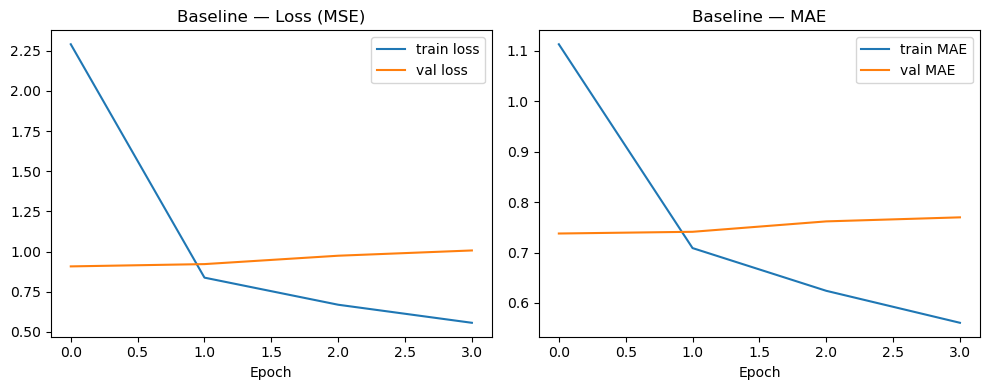

In [11]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_baseline.history['loss'],     label='train loss')
plt.plot(history_baseline.history['val_loss'], label='val loss')
plt.title('Baseline Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_baseline.history['mae'],     label='train MAE')
plt.plot(history_baseline.history['val_mae'], label='val MAE')
plt.title('Baseline MAE')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
rmse_b, mae_b = evaluate_model(
    baseline_model,
    {'user_idx': u_test, 'movie_idx': m_test},
    r_test,
    model_name='Baseline NCF'
)
results['Baseline NCF'] = {'RMSE': rmse_b, 'MAE': mae_b}


[Baseline NCF]  RMSE = 0.9464  |  MAE = 0.7370


## Multimodal Model


### Diagnostics


In [13]:
zero_poster_mask = ~poster_available
print(f'Movies with all-zero raw poster embeddings: {zero_poster_mask.sum()} / {len(poster_available)}')
print(f'Poster model matrix: shape={poster_embeddings.shape}, mean={poster_embeddings[:, :-1].mean():.3f}, std={poster_embeddings[:, :-1].std():.3f}')

rv = df.groupby('movie_idx')['rating'].agg(['var', 'count'])
print('\nPer-movie rating variance:')
print(f'  Mean   : {rv["var"].mean():.4f}')
print(f'  Median : {rv["var"].median():.4f}')
print(f'  Movies with variance > 1.0 : {(rv["var"] > 1.0).sum()} / {len(rv)}')

sample_idxs = df['movie_idx'].unique()
available_sample = sample_idxs[poster_available[sample_idxs]]
if len(available_sample) > 2 and poster_embeddings.shape[1] > 2:
    poster_signal = poster_embeddings[available_sample, :-1]
    svd_diag = TruncatedSVD(n_components=1, random_state=SEED)
    poster_pc1 = svd_diag.fit_transform(poster_signal).flatten()
    avg_rating = df.groupby('movie_idx')['rating'].mean().loc[available_sample].values
    corr = np.corrcoef(poster_pc1, avg_rating)[0, 1]
    print(f'\nPearson corr(poster PC1, avg movie rating) = {corr:.4f}')
else:
    print('\nNot enough available posters for PC1 correlation diagnostic.')

print(f'\nBaseline trainable params: {baseline_model.count_params():,}')


Movies with all-zero raw poster embeddings: 819 / 59047
Poster model matrix: shape=(59047, 65), mean=-0.000, std=0.993

Per-movie rating variance:
  Mean   : 0.9933
  Median : 0.8317
  Movies with variance > 1.0 : 4468 / 18311

Pearson corr(poster PC1, avg movie rating) = -0.0189

Baseline trainable params: 7,097,089


In [14]:
def build_multimodal_model(n_users, n_movies, meta_dim, poster_dim, embed_dim=EMBEDDING_DIM):
    user_input   = keras.Input(shape=(1,),          name='user_idx',   dtype='int32')
    movie_input  = keras.Input(shape=(1,),          name='movie_idx',  dtype='int32')
    meta_input   = keras.Input(shape=(meta_dim,),   name='metadata')
    poster_input = keras.Input(shape=(poster_dim,), name='poster_emb')

    user_emb = layers.Embedding(
        n_users, embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='user_embedding'
    )(user_input)
    user_emb = layers.Flatten(name='user_flatten')(user_emb)

    movie_emb = layers.Embedding(
        n_movies, embed_dim,
        embeddings_regularizer=keras.regularizers.l2(1e-6),
        name='movie_embedding'
    )(movie_input)
    movie_emb = layers.Flatten(name='movie_flatten')(movie_emb)

    cf = layers.Concatenate(name='cf_features')([user_emb, movie_emb])
    cf = layers.Dense(64, activation='relu', name='cf_dense_1')(cf)
    cf = layers.Dense(32, activation='relu', name='cf_dense_2')(cf)
    cf_rating = layers.Dense(1, name='cf_rating')(cf)

    meta = layers.BatchNormalization(name='meta_bn')(meta_input)
    meta = layers.Dense(
        16,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='meta_dense_1'
    )(meta)
    meta = layers.Dropout(0.15, name='meta_dropout_1')(meta)

    poster = layers.BatchNormalization(name='poster_bn')(poster_input)
    poster = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='poster_dense_1'
    )(poster)
    poster = layers.Dropout(0.25, name='poster_dropout_1')(poster)

    side = layers.Concatenate(name='side_features')([meta, poster])
    side = layers.Dense(
        32,
        activation='relu',
        kernel_regularizer=keras.regularizers.l2(1e-4),
        name='side_dense_1'
    )(side)
    side = layers.Dropout(0.20, name='side_dropout_1')(side)
    residual = layers.Dense(
        1,
        kernel_initializer='zeros',
        bias_initializer='zeros',
        name='side_residual'
    )(side)

    output = layers.Add(name='rating_output')([cf_rating, residual])
    model = Model(
        inputs=[user_input, movie_input, meta_input, poster_input],
        outputs=output,
        name='Multimodal_NCF_residual'
    )
    return model


def copy_baseline_to_multimodal(baseline, multimodal):
    layer_pairs = {
        'user_embedding': 'user_embedding',
        'movie_embedding': 'movie_embedding',
        'cf_dense_1': 'cf_dense_1',
        'cf_dense_2': 'cf_dense_2',
        'rating_output': 'cf_rating',
    }
    for src_name, dst_name in layer_pairs.items():
        multimodal.get_layer(dst_name).set_weights(baseline.get_layer(src_name).get_weights())


def set_collaborative_trainable(model, trainable):
    for name in ['user_embedding', 'movie_embedding', 'cf_dense_1', 'cf_dense_2', 'cf_rating']:
        model.get_layer(name).trainable = trainable


multi_model = build_multimodal_model(N_USERS, N_MOVIES, META_DIM, POSTER_DIM)
copy_baseline_to_multimodal(baseline_model, multi_model)
set_collaborative_trainable(multi_model, False)

multi_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3, clipnorm=1.0),
    loss='mse',
    metrics=['mae']
)

multi_model.summary()
print(f'Multimodal params: total={multi_model.count_params():,}, trainable side branch only')


Model: "Multimodal_NCF_residual"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ metadata            │ (None, 34)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_emb          │ (None, 65)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_idx            │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_idx           │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_bn             │ (None, 34)        │        136 │ metadata[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_bn           │ (None, 65)        │        260 │ poster_emb[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_embedding      │ (None, 1, 32)     │  5,201,312 │ user_idx[0][0]    │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_embedding     │ (None, 1, 32)     │  1,889,504 │ movie_idx[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_dense_1        │ (None, 16)        │        560 │ meta_bn[0][0]     │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_dense_1      │ (None, 32)        │      2,112 │ poster_bn[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ user_flatten        │ (None, 32)        │          0 │ user_embedding[0… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ movie_flatten       │ (None, 32)        │          0 │ movie_embedding[… │
│ (Flatten)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ meta_dropout_1      │ (None, 16)        │          0 │ meta_dense_1[0][… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ poster_dropout_1    │ (None, 32)        │          0 │ poster_dense_1[0… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_features         │ (None, 64)        │          0 │ user_flatten[0][… │
│ (Concatenate)       │                   │            │ movie_flatten[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ side_features       │ (None, 48)        │          0 │ meta_dropout_1[0… │
│ (Concatenate)       │                   │            │ poster_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ cf_dense_1 (Dense)  │ (None, 64)        │      4,160 │ cf_features[0][0

 Total params: 7,101,758 (27.09 MB)

 Trainable params: 4,471 (17.46 KB)

 Non-trainable params: 7,097,287 (27.07 MB)

Multimodal params: total=7,101,758, trainable side branch only


In [15]:
multi_train_inputs = {
    'user_idx'  : u_train,
    'movie_idx' : m_train,
    'metadata'  : meta_train,
    'poster_emb': poster_train,
}
multi_val_inputs = {
    'user_idx'  : u_val,
    'movie_idx' : m_val,
    'metadata'  : meta_val,
    'poster_emb': poster_val,
}

initial_weights = multi_model.get_weights()
initial_val_pred = multi_model.predict(multi_val_inputs, batch_size=BATCH_SIZE, verbose=0).flatten()
initial_val_pred = np.clip(initial_val_pred, RATING_MIN, RATING_MAX)
initial_val_rmse = np.sqrt(mean_squared_error(r_val, initial_val_pred))
print(f'Initial multimodal validation RMSE (baseline-equivalent): {initial_val_rmse:.4f}')

early_stop_multi = keras.callbacks.EarlyStopping(
    monitor='val_mae', mode='min', patience=4, restore_best_weights=True
)
reduce_lr_multi = keras.callbacks.ReduceLROnPlateau(
    monitor='val_mae', mode='min', factor=0.5, patience=2, min_lr=1e-6, verbose=1
)

history_multi = multi_model.fit(
    x=multi_train_inputs,
    y=r_train,
    validation_data=(multi_val_inputs, r_val),
    batch_size=BATCH_SIZE,
    epochs=EPOCHS_MULTI,
    callbacks=[early_stop_multi, reduce_lr_multi],
    verbose=1
)

trained_weights = multi_model.get_weights()
alpha_grid = np.linspace(0.0, 1.0, 21)
best_alpha = 0.0
best_val_rmse = initial_val_rmse
best_weights = initial_weights

for alpha in alpha_grid[1:]:
    multi_model.set_weights(trained_weights)
    residual_layer = multi_model.get_layer('side_residual')
    residual_weights = residual_layer.get_weights()
    residual_layer.set_weights([residual_weights[0] * alpha, residual_weights[1] * alpha])

    val_pred = multi_model.predict(multi_val_inputs, batch_size=BATCH_SIZE, verbose=0).flatten()
    val_pred = np.clip(val_pred, RATING_MIN, RATING_MAX)
    val_rmse = np.sqrt(mean_squared_error(r_val, val_pred))
    if val_rmse < best_val_rmse - 1e-5:
        best_alpha = float(alpha)
        best_val_rmse = float(val_rmse)
        best_weights = multi_model.get_weights()

multi_model.set_weights(best_weights)
if best_alpha == 0.0:
    print('Side residual did not improve validation RMSE; restored baseline-equivalent multimodal weights.')
else:
    print(f'Best residual alpha on validation: {best_alpha:.2f} (RMSE {best_val_rmse:.4f})')


Initial multimodal validation RMSE (baseline-equivalent): 0.9514
Epoch 1/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.7492 - mae: 0.6600 - val_loss: 0.9054 - val_mae: 0.7341 - learning_rate: 0.0010
Epoch 2/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7441 - mae: 0.6585 - val_loss: 0.9017 - val_mae: 0.7331 - learning_rate: 0.0010
Epoch 3/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.7424 - mae: 0.6581 - val_loss: 0.9007 - val_mae: 0.7332 - learning_rate: 0.0010
Epoch 4/20
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.8070 - mae: 0.6904
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7415 - mae: 0.6578 - val_loss: 0.9004 - val_mae: 0.7330 - learning_rate: 0.0010
Epoch 5/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7406 - mae: 0.6574 - val_loss: 0.8996 - val_mae: 0.7333 - learning_rate: 5.0000e-04
Epoch 6/20
391/391 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.7401 - mae: 0

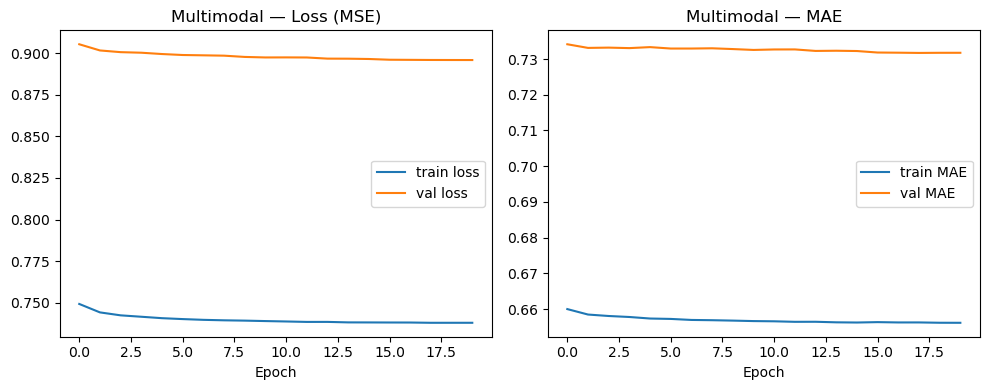

In [16]:
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_multi.history['loss'],     label='train loss')
plt.plot(history_multi.history['val_loss'], label='val loss')
plt.title('Multimodal Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_multi.history['mae'],     label='train MAE')
plt.plot(history_multi.history['val_mae'], label='val MAE')
plt.title('Multimodal MAE')
plt.legend()
plt.tight_layout()
plt.show()


In [17]:
rmse_m, mae_m = evaluate_model(
    multi_model,
    {
        'user_idx'  : u_test,
        'movie_idx' : m_test,
        'metadata'  : meta_test,
        'poster_emb': poster_test
    },
    r_test,
    model_name='Multimodal NCF'
)
results['Multimodal NCF'] = {'RMSE': rmse_m, 'MAE': mae_m}


[Multimodal NCF]  RMSE = 0.9403  |  MAE = 0.7311


## Comparison



=== Model Comparison (Test Set) ===
                 RMSE    MAE  RMSE_improvement_%
Baseline NCF   0.9464 0.7370              0.0000
Multimodal NCF 0.9403 0.7311              0.6500


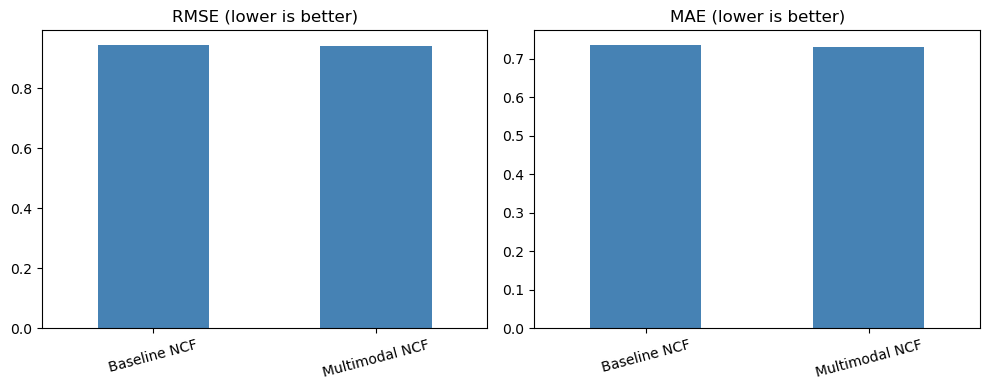


=== Architecture Comparison ===
                            User Embedding             Movie Embedding               Metadata                           Poster CNN Total Params Trainable Params
Model                                                                                                                                                           
Baseline NCF                  Yes (32-dim)                Yes (32-dim)                     No                                   No    7,097,089        7,097,089
Multimodal NCF  Yes (32-dim, warm-started)  Yes (32-dim, warm-started)  Yes (34-dim residual)  Yes (64 visual + availability flag)    7,101,758            4,471


In [18]:
comparison_df = pd.DataFrame(results).T
comparison_df['RMSE_improvement_%'] = (
    (comparison_df.loc['Baseline NCF', 'RMSE'] - comparison_df['RMSE'])
    / comparison_df.loc['Baseline NCF', 'RMSE'] * 100
).round(2)

print('\n=== Model Comparison (Test Set) ===')
print(comparison_df.to_string(float_format='{:.4f}'.format))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
comparison_df[['RMSE']].plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], legend=False)
axes[0].set_title('RMSE')
axes[0].set_xticklabels(comparison_df.index, rotation=15)

comparison_df[['MAE']].plot(kind='bar', ax=axes[1], color=['steelblue', 'coral'], legend=False)
axes[1].set_title('MAE')
axes[1].set_xticklabels(comparison_df.index, rotation=15)
plt.tight_layout()
plt.show()


def trainable_param_count(model):
    return int(np.sum([np.prod(v.shape) for v in model.trainable_weights]))

arch_df = pd.DataFrame({
    'Model': ['Baseline NCF', 'Multimodal NCF'],
    'User Embedding': [f'Yes ({EMBEDDING_DIM}-dim)', f'Yes ({EMBEDDING_DIM}-dim, warm-started)'],
    'Movie Embedding': [f'Yes ({EMBEDDING_DIM}-dim)', f'Yes ({EMBEDDING_DIM}-dim, warm-started)'],
    'Metadata': ['No', f'Yes ({META_DIM}-dim residual)'],
    'Poster CNN': ['No', f'Yes ({POSTER_DIM - 1} visual + availability flag)'],
    'Total Params': [f'{baseline_model.count_params():,}', f'{multi_model.count_params():,}'],
    'Trainable Params': [f'{trainable_param_count(baseline_model):,}', f'{trainable_param_count(multi_model):,}'],
}).set_index('Model')

print('\n=== Architecture Comparison ===')
print(arch_df.to_string())


## Recommendations


In [19]:
def recommend_top_n(model, user_id, df_all, poster_emb_arr, meta_lookup_arr,
                    n=10, use_multimodal=False):
    seen_movies = set(df_all[df_all['user_idx'] == user_id]['movie_idx'].values)
    all_movies  = np.arange(N_MOVIES)
    unseen      = np.array([m for m in all_movies if m not in seen_movies])

    users_arr   = np.full(len(unseen), user_id, dtype=np.int32)
    movies_arr  = unseen.astype(np.int32)

    if use_multimodal:
        inputs = {
            'user_idx'  : users_arr,
            'movie_idx' : movies_arr,
            'metadata'  : meta_lookup_arr[movies_arr],
            'poster_emb': poster_emb_arr[movies_arr]
        }
    else:
        inputs = {'user_idx': users_arr, 'movie_idx': movies_arr}

    preds = model.predict(inputs, batch_size=2048, verbose=0).flatten()
    preds = np.clip(preds, RATING_MIN, RATING_MAX)
    top_n_idx = np.argsort(preds)[::-1][:n]
    top_movies = unseen[top_n_idx]
    top_scores = preds[top_n_idx]

    movie_info = df_all[['movie_idx','final_title']].drop_duplicates('movie_idx').set_index('movie_idx')
    recs = []
    for m_idx, score in zip(top_movies, top_scores):
        title = movie_info.loc[m_idx, 'final_title'] if m_idx in movie_info.index else f'movie_{m_idx}'
        recs.append({'movie_idx': m_idx, 'title': title, 'predicted_rating': round(float(score), 3)})
    return pd.DataFrame(recs)


DEMO_USER = 0
print(f'Top-10 recommendations for user_idx={DEMO_USER}')
print('\n--- Baseline Model ---')
print(recommend_top_n(baseline_model, DEMO_USER, df, poster_embeddings, meta_lookup,
                      n=10, use_multimodal=False).to_string(index=False))

print('\n--- Multimodal Model ---')
print(recommend_top_n(multi_model, DEMO_USER, df, poster_embeddings, meta_lookup,
                      n=10, use_multimodal=True).to_string(index=False))


Top-10 recommendations for user_idx=0

--- Baseline Model ---
 movie_idx                    title  predicted_rating
      3002      The Grapes of Wrath             4.091
       909                Notorious             4.058
       314 The Shawshank Redemption             4.058
     22823               Wild Tales             4.052
       840            The Godfather             4.051
       905            All About Eve             4.045
      4131            Amores perros             4.015
      1177           Apocalypse Now             4.007
      1059        Dial M for Murder             3.984
     10700      The Lives of Others             3.976

--- Multimodal Model ---
 movie_idx                                                title  predicted_rating
     38361                                         Planet Earth             4.303
     42953                                      Planet Earth II             4.267
       707             The Haunted World of Edward D. Wood, Jr.         

## Save Models


In [20]:
save_dir = DATA_DIR / 'saved_models'
save_dir.mkdir(parents=True, exist_ok=True)

baseline_model.save(save_dir / 'baseline_ncf.keras')
multi_model.save(save_dir / 'multimodal_ncf.keras')

print('Models saved to:', save_dir)
print('  baseline_ncf.keras')
print('  multimodal_ncf.keras')


Models saved to: /home/muribr/neural network group project/saved_models
  baseline_ncf.keras
  multimodal_ncf.keras


Set `USE_SAMPLE = False` for full training.
